In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:

import os
os.getcwd()

'/content'

In [47]:
df = pd.read_csv("/content/airlines_flights_data.csv")

In [48]:
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# TASK 1: DATA EXPLORATION

In [49]:
import pandas as pd

df = pd.read_csv("airlines_flights_data.csv")

print(df.head())

print(df.info())

print(df.describe())

print("Shape:", df.shape)

print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

print(df.dtypes)

   index   airline   flight source_city departure_time stops   arrival_time  \
0      0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1      1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2      2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3      3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4      4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------       

In [50]:
print(df.columns)

Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')


# TASK 2: UNIVARIATE ANALYSIS

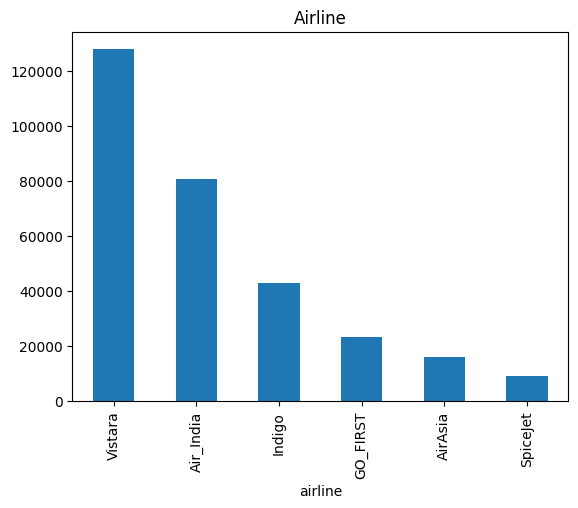

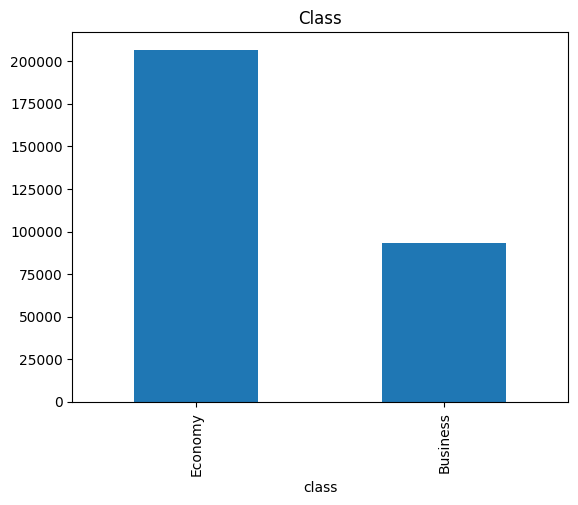

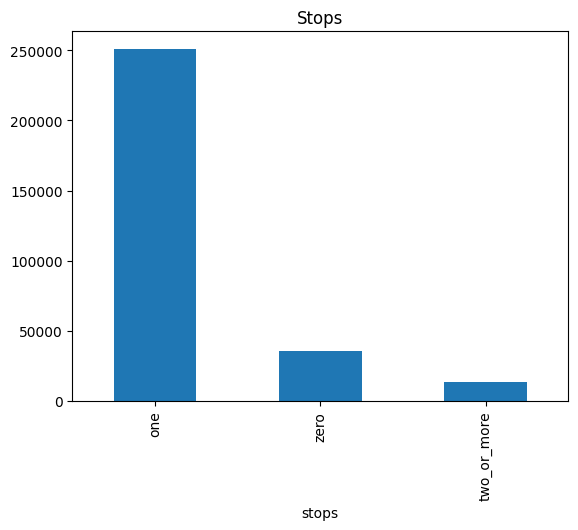

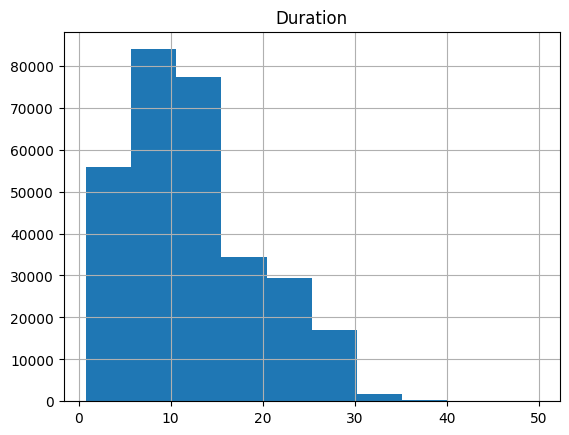

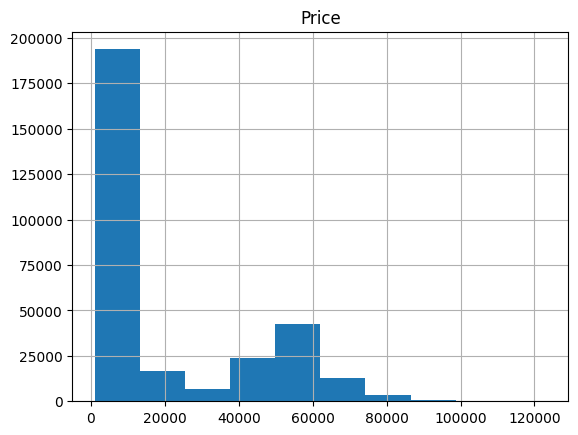

In [51]:

import matplotlib.pyplot as plt

df['airline'].value_counts().plot(kind='bar')
plt.title("Airline")
plt.show()

df['class'].value_counts().plot(kind='bar')
plt.title("Class")
plt.show()

df['stops'].value_counts().plot(kind='bar')
plt.title("Stops")
plt.show()

df['duration'].hist()
plt.title("Duration")
plt.show()

df['price'].hist()
plt.title("Price")
plt.show()

# TASK 3: BIVARIATE ANALYSIS

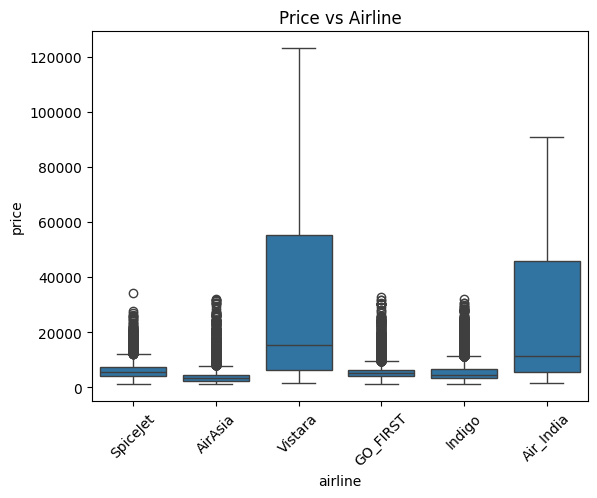

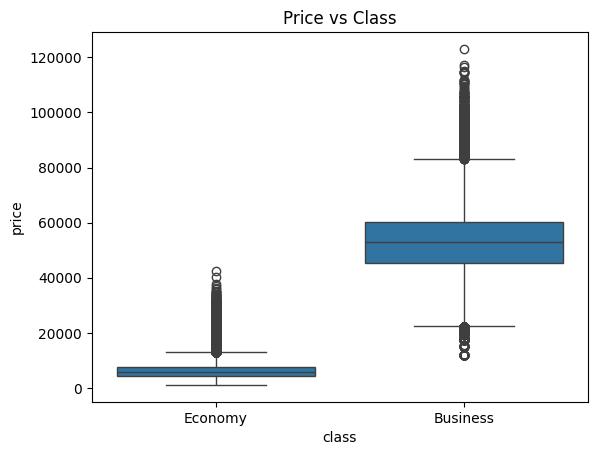

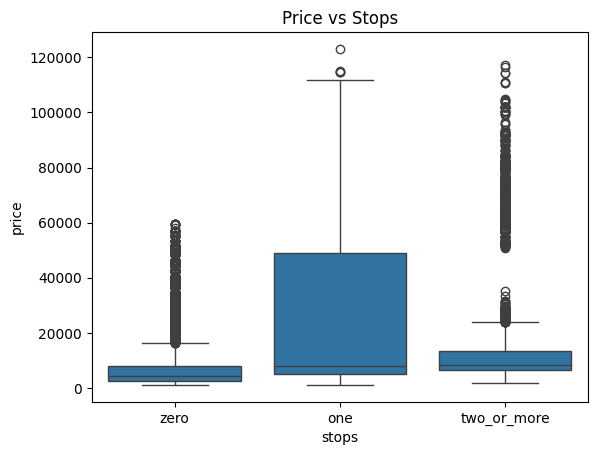

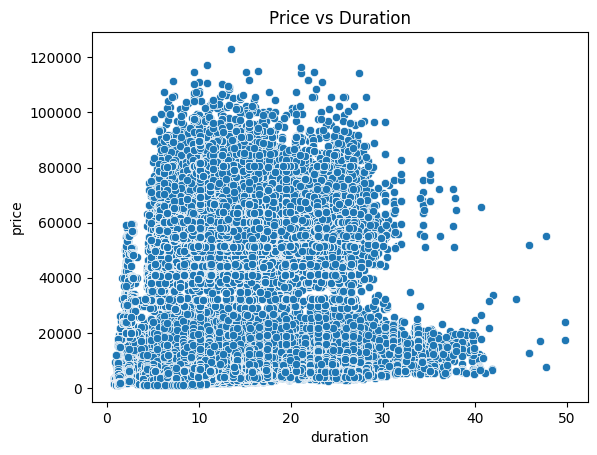

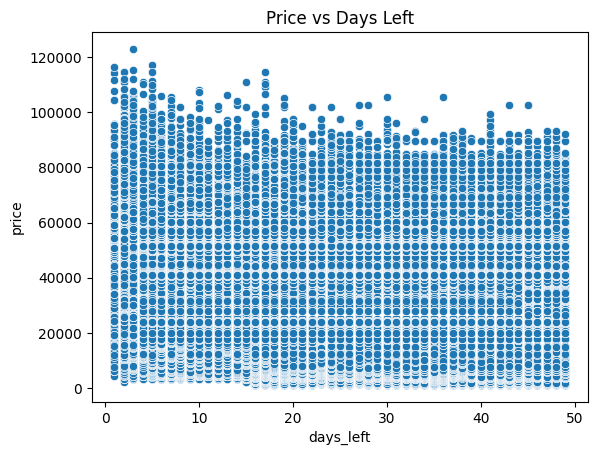

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("airlines_flights_data.csv")

# Price vs Airline
sns.boxplot(x="airline", y="price", data=df)
plt.title("Price vs Airline")
plt.xticks(rotation=45)
plt.show()

# Price vs Class
sns.boxplot(x="class", y="price", data=df)
plt.title("Price vs Class")
plt.show()

# Price vs Stops
sns.boxplot(x="stops", y="price", data=df)
plt.title("Price vs Stops")
plt.show()

# Price vs Duration
sns.scatterplot(x="duration", y="price", data=df)
plt.title("Price vs Duration")
plt.show()

# Price vs Days Left
sns.scatterplot(x="days_left", y="price", data=df)
plt.title("Price vs Days Left")
plt.show()

# TASK 4: CORRELATION AND FEATURE ENGINEERING

              index   airline     stops     class  duration  days_left  \
index      1.000000  0.179822 -0.123422 -0.802099  0.159007   0.014638   
airline    0.179822  1.000000 -0.029838 -0.178862 -0.001651  -0.010678   
stops     -0.123422 -0.029838  1.000000  0.100262 -0.473860  -0.007047   
class     -0.802099 -0.178862  0.100262  1.000000 -0.138710   0.013039   
duration   0.159007 -0.001651 -0.473860 -0.138710  1.000000  -0.039157   
days_left  0.014638 -0.010678 -0.007047  0.013039 -0.039157   1.000000   
price      0.761177  0.243358 -0.202620 -0.937860  0.204222  -0.091949   

              price  
index      0.761177  
airline    0.243358  
stops     -0.202620  
class     -0.937860  
duration   0.204222  
days_left -0.091949  
price      1.000000  


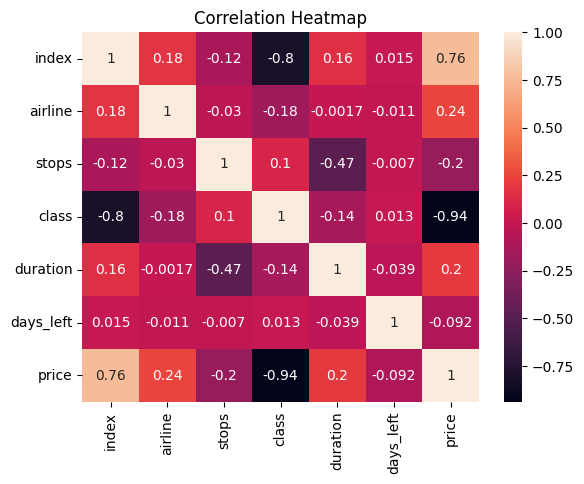

   index  airline   flight source_city departure_time  stops   arrival_time  \
0      0        4  SG-8709       Delhi        Evening      2          Night   
1      1        4  SG-8157       Delhi  Early_Morning      2        Morning   
2      2        0   I5-764       Delhi  Early_Morning      2  Early_Morning   
3      3        5   UK-995       Delhi        Morning      2      Afternoon   
4      4        5   UK-963       Delhi        Morning      2        Morning   

  destination_city  class  duration  days_left  price  price_per_day  \
0           Mumbai      1      2.17          1   5953         2976.5   
1           Mumbai      1      2.33          1   5953         2976.5   
2           Mumbai      1      2.17          1   5956         2978.0   
3           Mumbai      1      2.25          1   5955         2977.5   
4           Mumbai      1      2.33          1   5955         2977.5   

   long_flight  
0        False  
1        False  
2        False  
3        False  
4      

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("airlines_flights_data.csv")

# Encode categorical variables
df["airline"] = df["airline"].astype("category").cat.codes
df["class"] = df["class"].astype("category").cat.codes
df["stops"] = df["stops"].astype("category").cat.codes

# Select numerical columns
data = df.select_dtypes(include="number")

# Correlation
corr = data.corr()

print(corr)

# Heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Feature 1: Price per day left
df["price_per_day"] = df["price"] / (df["days_left"] + 1)

# Feature 2: Duration category
df["long_flight"] = df["duration"] > df["duration"].mean()

print(df.head())

# TASK 5: BUSINESS INSIGHTS

In [54]:
import pandas as pd

# Load dataset
df = pd.read_csv("airlines_flights_data.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())


# TOP 5 BUSINESS INSIGHTS

print("\n----- TOP 5 BUSINESS INSIGHTS -----")

print("1. Ticket prices vary between different airlines.")

print("2. Business class tickets are generally more expensive than economy class.")

print("3. Flight duration can affect ticket prices.")

print("4. Ticket prices can change depending on the number of days left.")

print("5. The number of stops can affect ticket prices.")


# RECOMMENDATIONS

print("\n----- RECOMMENDATIONS -----")
print("1. Airlines can use dynamic pricing based on demand.")

print("2. Airlines can provide offers to attract more customers.")

print("3. Airlines can use flight data to improve their pricing strategies.")

Dataset Shape: (300153, 12)

Missing Values:
index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Basic Statistics:
               index       duration      days_left          price
count  300153.000000  300153.000000  300153.000000  300153.000000
mean   150076.000000      12.221021      26.004751   20889.660523
std     86646.852011       7.191997      13.561004   22697.767366
min         0.000000       0.830000       1.000000    1105.000000
25%     75038.000000       6.830000      15.000000    4783.000000
50%    150076.000000      11.250000      26.000000    7425.000000
75%    225114.000000      16.170000      38.000000   42521.000000
max    300152.000000      49.830000      49.000000  123071.000000

----- TOP 5 BUSINESS INSIGHTS -----
1. Ticket prices vary betwee